# Setup

In [18]:
%reload_ext autoreload
%autoreload 2

In [19]:
import pymonntorch
pymonntorch.__version__

'0.1.4'

In [20]:
import torch
from pymonntorch import *
from conex import *

import json

from matplotlib import pyplot as plt
import numpy as np

from Sequence import Sequence
from Simulation import Simulation

# Params

In [11]:
from params_6_SNN import params_base, params_c0, params_c1, params_c2, params_c3

# Scenario Matrix

In [6]:
params = np.linspace(0.01, 0.049, 40)
params

array([0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018,
       0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026, 0.027,
       0.028, 0.029, 0.03 , 0.031, 0.032, 0.033, 0.034, 0.035, 0.036,
       0.037, 0.038, 0.039, 0.04 , 0.041, 0.042, 0.043, 0.044, 0.045,
       0.046, 0.047, 0.048, 0.049])

In [4]:
param_result = np.ones((40, 40))
params = np.linspace(0.01, 0.049, 5)

u = 0
for i in params : 
    v = 0
    for j in params : 
        params_base["COOP12"] = i,
        params_base["COOP21"] = j,

        sim = Simulation(params_base)
        param_result[u][v] = sim.run()[0]
        v += 1
    u += 1

param_result_json = param_result.tolist()
json_file_path = 'new_data.json'
with open(json_file_path, 'w') as json_file:
    json.dump(param_result_json, json_file)

print("parameter results have been saved successfully")

parameter results have been saved successfully


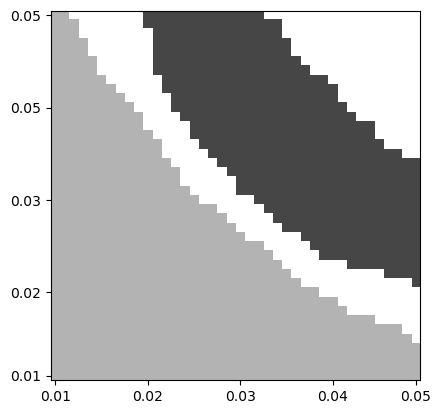

In [95]:
json_file_path = 'param_result.json'

with open(json_file_path, 'r') as json_file:
    param_result = json.load(json_file)


param_result = np.array(param_result)

param_result[param_result == 1] = 70
param_result[param_result == 2] = 180
param_result[param_result == 0] = 255

plt.imshow(param_result, cmap = "gray", vmin = 0, vmax = 255)
plt.xticks([])  
 
plt.xticks([0,10, 20,30, 39], labels = ["0.01", "0.02", "0.03", "0.04","0.05"])
plt.yticks([0,10, 20,30, 39], labels = ["0.05", "0.05", "0.03", "0.02", "0.01"])

plt.savefig('./scenario_matrix.svg')
plt.show()

# Activities of examples

In [37]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(1) : 
    params_c3["COOP12"] = params_c3["COOP21"] = 0.067
    sim = Simulation(params = params_c3)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C3 : Executed on 10 simulations successfully")

Network['Network_1', 'Network'](Neurons: tensor(75000)|180 groups, Synapses: tensor(201937500)|1093 groups){1:TimeResolution(dt=1,)}
NeuronGroup['exi', 'NeuronGroup', 'ng'](1000){220:SimpleDendriteStructure(Proximal_max_delay=1,Distal_max_delay=1,Apical_max_delay=None,proximal_min_delay=0,distal_min_delay=0,apical_min_delay=None,)240:SimpleDendriteComputation(I_tau=None,apical_provocativeness=None,distal_provocativeness=None,)250:InitialActivation()259:BackgroundActivityCurrentBased()260:AELIF(R=0.55,tau=7,threshold=-45,v_reset=-70,v_rest=-65,init_v=tensor([-70.0353, -65.1183, -61.5098, -54.7428, -99.3008, -54.0728, -64.3031,
        -86.9639, -77.7634, -82.6398, -85.1819, -58.6472, -62.4274, -59.5789,
        -50.6464, -86.6265, -54.8479, -67.5885, -88.5928, -51.5737, -78.3337,
        -90.4569, -69.9090, -59.7975, -62.4881, -68.5515, -86.2732, -92.9572,
        -96.5160, -64.7987, -67.3235, -69.9041, -79.5149, -94.6881, -95.6104,
        -95.3543, -76.8470, -98.3946, -59.1213, -67.26

### c3

In [38]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125


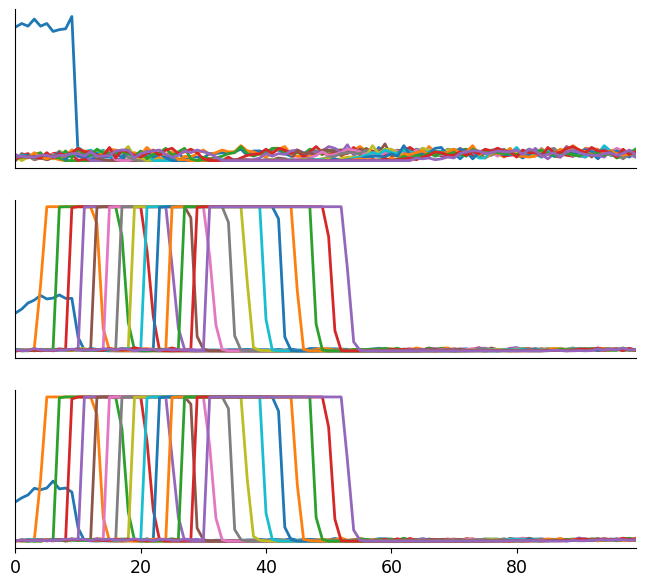

In [39]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
plt.savefig('./act_c3.svg')
plt.show()

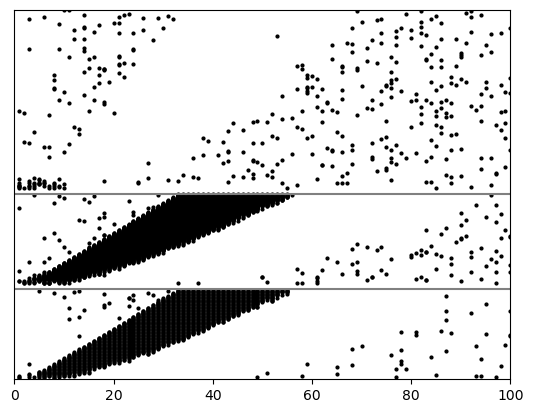

In [40]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

plt.savefig('./rast_c3.svg')
plt.show()

### c2

In [21]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(1) : 
    sim = Simulation(params = params_c2)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C2 : Executed on 10 simulations successfully")

Network['Network_1', 'Network'](Neurons: tensor(75000)|180 groups, Synapses: tensor(201937500)|1093 groups){1:TimeResolution(dt=1,)}
NeuronGroup['exi', 'NeuronGroup', 'ng'](1000){220:SimpleDendriteStructure(Proximal_max_delay=1,Distal_max_delay=1,Apical_max_delay=None,proximal_min_delay=0,distal_min_delay=0,apical_min_delay=None,)240:SimpleDendriteComputation(I_tau=None,apical_provocativeness=None,distal_provocativeness=None,)250:InitialActivation()259:BackgroundActivityCurrentBased()260:AELIF(R=0.55,tau=7,threshold=-45,v_reset=-70,v_rest=-65,init_v=tensor([-50.4435, -65.4201, -90.8388, -52.4571, -94.0161, -97.3932, -50.9397,
        -75.2989, -69.1290, -53.5659, -67.2059, -76.2054, -72.4436, -81.3684,
        -79.5364, -72.4007, -77.9845, -98.6456, -64.7118, -80.5678, -56.9509,
        -59.6753, -95.8320, -78.4005, -82.8027, -63.1980, -99.4296, -56.2832,
        -77.9550, -64.3608, -97.4932, -55.3288, -97.2896, -91.3620, -57.8782,
        -53.3373, -84.7428, -99.8499, -90.9240, -70.93

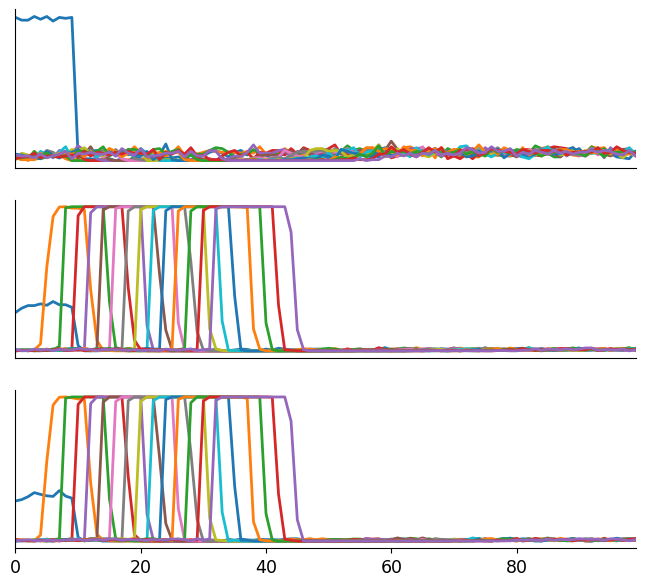

In [22]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])
# plt.ylim(0, 0.52)

plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
plt.savefig('./act_c2.svg')
plt.show()

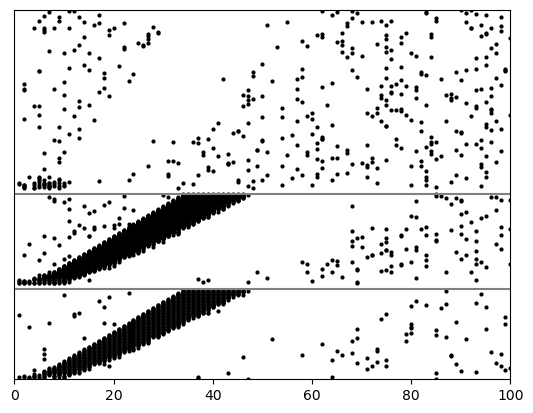

In [23]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

plt.savefig('./rast_c2.svg')
plt.show()

### c1

In [24]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(1) : 
    sim = Simulation(params = params_c1)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C1 : Executed on 10 simulations successfully")

Network['Network_1', 'Network'](Neurons: tensor(75000)|180 groups, Synapses: tensor(201937500)|1093 groups){1:TimeResolution(dt=1,)}
NeuronGroup['exi', 'NeuronGroup', 'ng'](1000){220:SimpleDendriteStructure(Proximal_max_delay=1,Distal_max_delay=1,Apical_max_delay=None,proximal_min_delay=0,distal_min_delay=0,apical_min_delay=None,)240:SimpleDendriteComputation(I_tau=None,apical_provocativeness=None,distal_provocativeness=None,)250:InitialActivation()259:BackgroundActivityCurrentBased()260:AELIF(R=0.55,tau=7,threshold=-45,v_reset=-70,v_rest=-65,init_v=tensor([-62.2479, -94.3524, -63.9827, -56.2385, -59.7110, -87.1448, -59.9188,
        -82.6443, -84.9650, -82.8217, -73.5372, -56.6377, -97.5379, -86.7305,
        -59.4941, -77.6681, -78.5814, -58.7486, -57.4111, -68.3279, -96.2374,
        -73.7881, -79.1646, -83.5742, -50.7499, -86.5803, -78.3238, -55.5852,
        -69.3283, -56.6822, -81.2911, -61.5672, -93.0462, -62.9273, -61.1888,
        -55.9069, -83.8338, -80.9744, -62.4355, -62.29

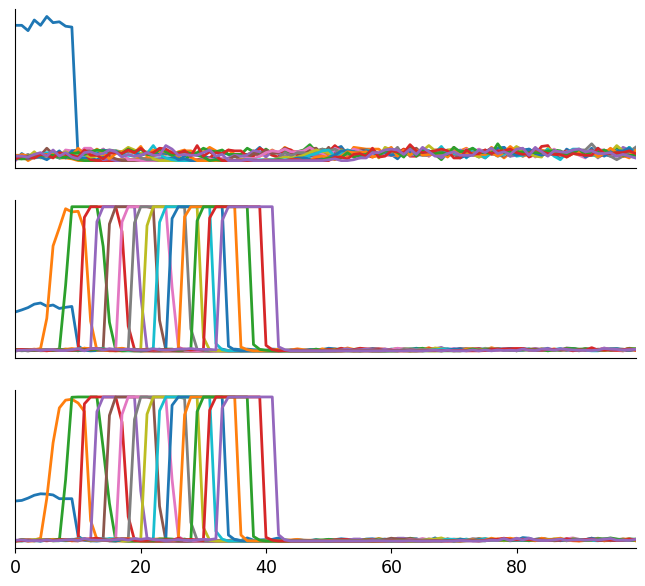

In [29]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
plt.savefig('./act_c1.svg')
plt.show()

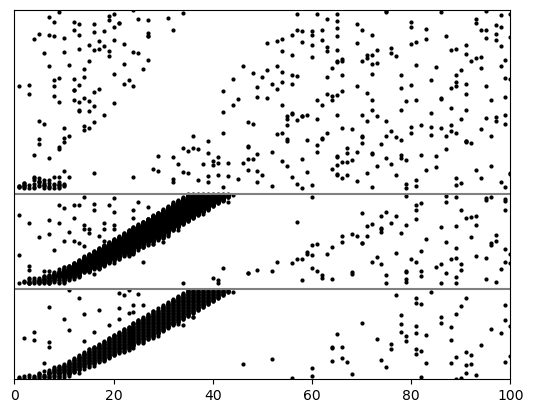

In [26]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

plt.savefig('./rast_c1.svg')
plt.show()

### c0

In [30]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

# params_c0["P_RC"] = 0.035
params_c0["COOP21"] = params_c0["COOP12"] = 0.025
params_c0["P_RC"] = 0.033
for _ in range(1) : 
    sim = Simulation(params = params_c0)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C0 : Executed on 10 simulations successfully")

Network['Network_1', 'Network'](Neurons: tensor(75000)|180 groups, Synapses: tensor(201937500)|1093 groups){1:TimeResolution(dt=1,)}
NeuronGroup['exi', 'NeuronGroup', 'ng'](1000){220:SimpleDendriteStructure(Proximal_max_delay=1,Distal_max_delay=1,Apical_max_delay=None,proximal_min_delay=0,distal_min_delay=0,apical_min_delay=None,)240:SimpleDendriteComputation(I_tau=None,apical_provocativeness=None,distal_provocativeness=None,)250:InitialActivation()259:BackgroundActivityCurrentBased()260:AELIF(R=0.55,tau=7,threshold=-45,v_reset=-70,v_rest=-65,init_v=tensor([-99.2401, -77.3234, -57.1397, -87.3595, -62.6507, -61.7669, -89.9470,
        -97.9555, -85.3276, -99.7139, -68.5524, -81.9518, -50.9787, -95.5545,
        -53.0224, -83.1878, -53.3289, -84.0719, -62.8244, -69.5967, -59.0093,
        -90.5518, -76.6127, -88.2182, -76.5095, -58.0414, -55.6972, -76.4128,
        -81.1739, -94.7799, -76.4925, -53.4944, -61.3740, -56.3877, -63.2514,
        -67.1574, -52.6284, -81.5637, -89.1084, -90.31

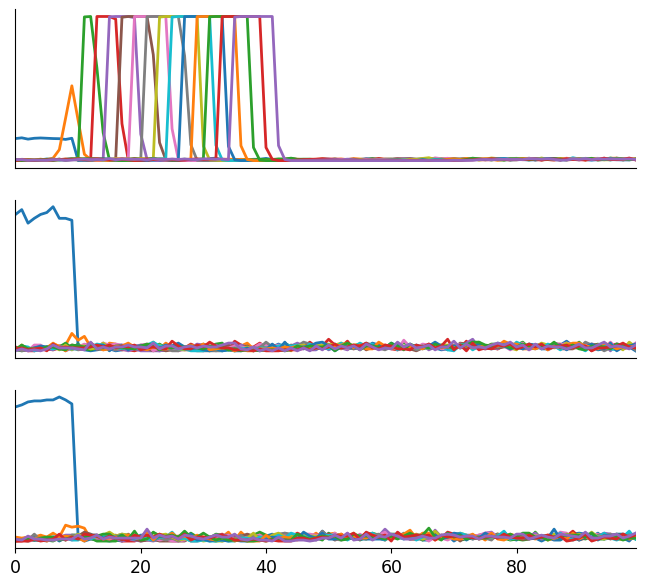

In [31]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
plt.savefig('./act_c0.svg')
plt.show()

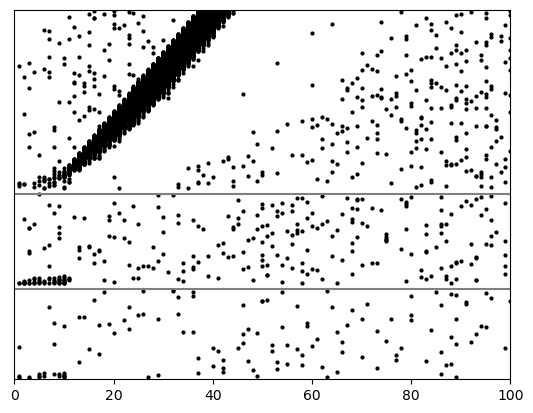

In [32]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

plt.savefig('./rast_c0.svg')